In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# Project path
BASE = Path(r"C:\Users\Renuka\Desktop\Customer Revenue & Delivery Intelligence Dashboard")

# Clean exported data path
DATA_PATH = BASE / "data" / "processed_data" / "powerbi"

# Load clean master dataset
orders = pd.read_csv(DATA_PATH / "orders_master.csv")

print("Rows and columns:", orders.shape)
orders.head()

Rows and columns: (99441, 30)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_city,customer_state,...,payment_row_count,payment_type_count,max_installments,item_row_count,unique_product_count,unique_seller_count,total_item_price,total_freight_value,total_order_item_value,product_categories
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,sao paulo,SP,...,3.0,2.0,1.0,1.0,1.0,1.0,29.99,8.72,38.71,housewares
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,barreiras,BA,...,1.0,1.0,1.0,1.0,1.0,1.0,118.70,22.76,141.46,perfumery
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,vianopolis,GO,...,1.0,1.0,3.0,1.0,1.0,1.0,159.90,19.22,179.12,auto
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,sao goncalo do amarante,RN,...,1.0,1.0,1.0,1.0,1.0,1.0,45.00,27.20,72.20,pet_shop
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,santo andre,SP,...,1.0,1.0,1.0,1.0,1.0,1.0,19.90,8.72,28.62,stationery


In [10]:
# Make pandas show longer text in tables
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_rows", 100)

# Simple feature summary table
# One column explains the values:
# - numeric columns = range
# - date columns = date range
# - categorical columns = list of categories
# - unique ID/text columns = one example + unique count

def summarize_feature(col_name):
    col = orders[col_name]
    non_missing = col.dropna()
    unique_count = non_missing.nunique()

    # Empty column
    if non_missing.empty:
        return "No non-missing values"

    # Date/timestamp columns
    if "date" in col_name.lower() or "timestamp" in col_name.lower() or "approved_at" in col_name.lower():
        dates = pd.to_datetime(non_missing, errors="coerce").dropna()
        if not dates.empty:
            return f"{dates.min().strftime('%Y-%m-%d')} to {dates.max().strftime('%Y-%m-%d')}"
        else:
            return f"Example: {non_missing.iloc[0]}"

    # Numeric columns
    if pd.api.types.is_numeric_dtype(col):
        min_value = col.min()
        max_value = col.max()

        # If values are whole numbers, show without decimals
        if float(min_value).is_integer() and float(max_value).is_integer():
            return f"{int(min_value)} to {int(max_value)}"
        else:
            return f"{round(min_value, 2)} to {round(max_value, 2)}"

    # Categorical columns with manageable number of categories
    if unique_count <= 30:
        categories = sorted(non_missing.astype(str).unique())
        return ", ".join(categories)

    # High-cardinality text columns like IDs or cities
    return f"Example: {non_missing.iloc[0]} ({unique_count} unique values)"


feature_summary_simple = pd.DataFrame({
    "feature": orders.columns,
    "data_type": orders.dtypes.astype(str).values,
    "missing_count": orders.isna().sum().values,
    "missing_percent": (orders.isna().mean() * 100).round(2).values,
    "values_or_range": [summarize_feature(col) for col in orders.columns]
})

feature_summary_simple



,feature,data_type,missing_count,missing_percent,values_or_range
0,order_id,object,0,0.00,Example: e481f51cbdc54678b7cc49136f2d6af7 (99441 unique values)
1,customer_id,object,0,0.00,Example: 9ef432eb6251297304e76186b10a928d (99441 unique values)
2,order_status,object,0,0.00,"approved, canceled, created, delivered, invoiced, processing, shipped, unavailable"
3,order_purchase_timestamp,object,0,0.00,2016-09-04 to 2018-10-17
4,order_approved_at,object,160,0.16,2016-09-15 to 2018-09-03
5,order_delivered_carrier_date,object,1783,1.79,2016-10-08 to 2018-09-11
6,order_delivered_customer_date,object,2965,2.98,2016-10-11 to 2018-10-17
7,order_estimated_delivery_date,object,0,0.00,2016-09-30 to 2018-11-12
8,customer_city,object,0,0.00,Example: sao paulo (4119 unique values)
9,customer_state,object,0,0.00,"AC, AL, AM, AP, BA, CE, DF, ES, GO, MA, MG, MS, MT, PA, PB, PE, PI, PR, RJ, RN, RO, RR, RS, SC, SE, SP, TO"


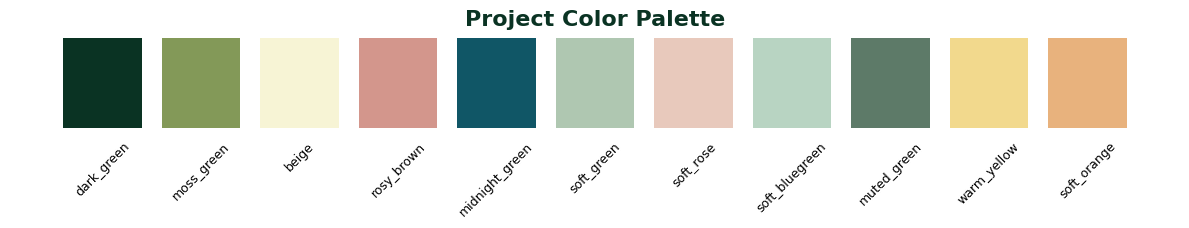

In [12]:
# Colors because I like to make this preety :) 
palette = {
    "dark_green": "#0A3323",
    "moss_green": "#839958",
    "beige": "#F7F4D5",
    "rosy_brown": "#D3968C",
    "midnight_green": "#105666",
    "soft_green": "#AFC7B1",
    "soft_rose": "#E8C9BC",
    "soft_bluegreen": "#B8D4C2",
    "muted_green": "#5D7A68",
    "warm_yellow": "#F2D98D",
    "soft_orange": "#E8B27D"
}

chart_colors = [
    palette["midnight_green"],
    palette["moss_green"],
    palette["rosy_brown"],
    palette["soft_green"],
    palette["warm_yellow"],
    palette["soft_orange"],
    palette["soft_bluegreen"]
]

# Preview the palette
fig, ax = plt.subplots(figsize=(12, 2.5))

for i, (name, color) in enumerate(palette.items()):
    ax.bar(i, 1, color=color)
    ax.text(i, -0.12, name, ha="center", va="top", rotation=45, fontsize=9)

ax.set_title(
    "Project Color Palette",
    fontsize=16,
    fontweight="bold",
    color=palette["dark_green"]
)

ax.set_xticks([])
ax.set_yticks([])
ax.set_frame_on(False)

plt.tight_layout()
plt.show()

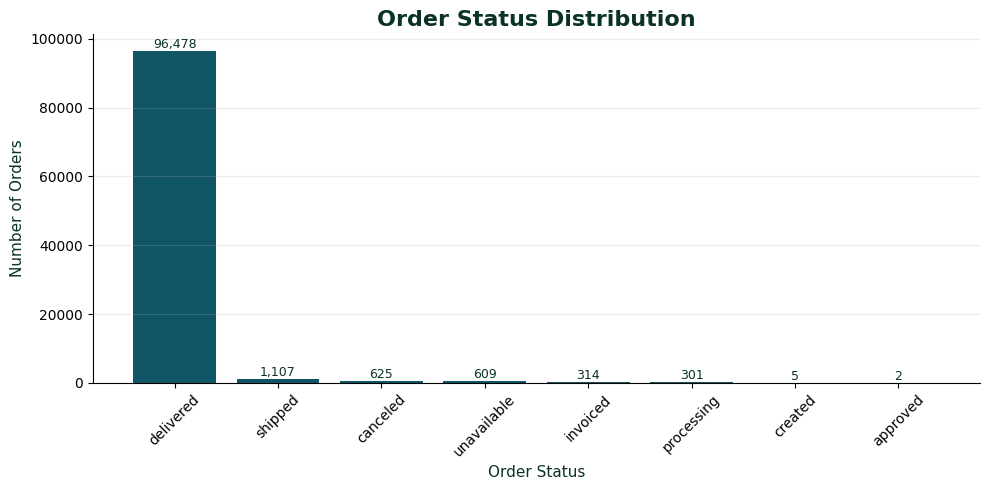

Saved chart to: C:\Users\Renuka\Desktop\Customer Revenue & Delivery Intelligence Dashboard\images\order_status_distribution.png


In [13]:
# Count orders by status
order_status_counts = (
    orders["order_status"]
    .value_counts()
    .reset_index()
)

order_status_counts.columns = ["order_status", "order_count"]

# Create figure
fig, ax = plt.subplots(figsize=(10, 5))

# Bar chart
bars = ax.bar(
    order_status_counts["order_status"],
    order_status_counts["order_count"],
    color=palette["midnight_green"]
)

# Title and labels
ax.set_title(
    "Order Status Distribution",
    fontsize=16,
    fontweight="bold",
    color=palette["dark_green"]
)

ax.set_xlabel("Order Status", fontsize=11, color=palette["dark_green"])
ax.set_ylabel("Number of Orders", fontsize=11, color=palette["dark_green"])

# Rotate x-axis labels
ax.tick_params(axis="x", rotation=45)

# Add light grid
ax.grid(axis="y", alpha=0.25)

# Remove top and right borders for cleaner look
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height):,}",
        ha="center",
        va="bottom",
        fontsize=9,
        color=palette["dark_green"]
    )

plt.tight_layout()

# Save chart
output_path = BASE / "images" / "order_status_distribution.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")

plt.show()

print("Saved chart to:", output_path)

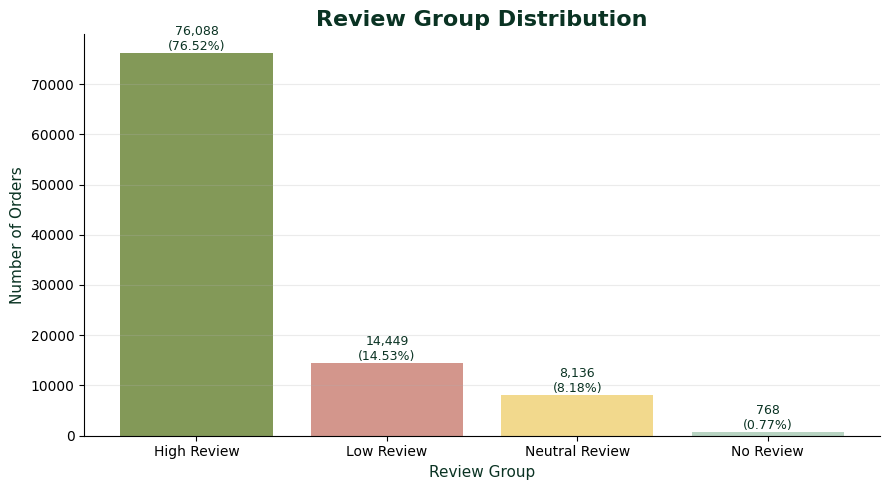

Saved chart to: C:\Users\Renuka\Desktop\Customer Revenue & Delivery Intelligence Dashboard\images\review_group_distribution.png


In [14]:
# Count review groups
review_group_counts = (
    orders["review_group"]
    .value_counts()
    .reset_index()
)

review_group_counts.columns = ["review_group", "order_count"]

# Calculate percentage
review_group_counts["percentage"] = (
    review_group_counts["order_count"] / review_group_counts["order_count"].sum() * 100
).round(2)

# Create figure
fig, ax = plt.subplots(figsize=(9, 5))

# Use our pastel palette
bars = ax.bar(
    review_group_counts["review_group"],
    review_group_counts["order_count"],
    color=[
        palette["moss_green"],
        palette["rosy_brown"],
        palette["warm_yellow"],
        palette["soft_bluegreen"]
    ]
)

# Title and labels
ax.set_title(
    "Review Group Distribution",
    fontsize=16,
    fontweight="bold",
    color=palette["dark_green"]
)

ax.set_xlabel("Review Group", fontsize=11, color=palette["dark_green"])
ax.set_ylabel("Number of Orders", fontsize=11, color=palette["dark_green"])

# Add value labels with percentages
for bar, percent in zip(bars, review_group_counts["percentage"]):
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height):,}\n({percent}%)",
        ha="center",
        va="bottom",
        fontsize=9,
        color=palette["dark_green"]
    )

# Clean style
ax.grid(axis="y", alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

# Save chart
output_path = BASE / "images" / "review_group_distribution.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")

plt.show()

print("Saved chart to:", output_path)

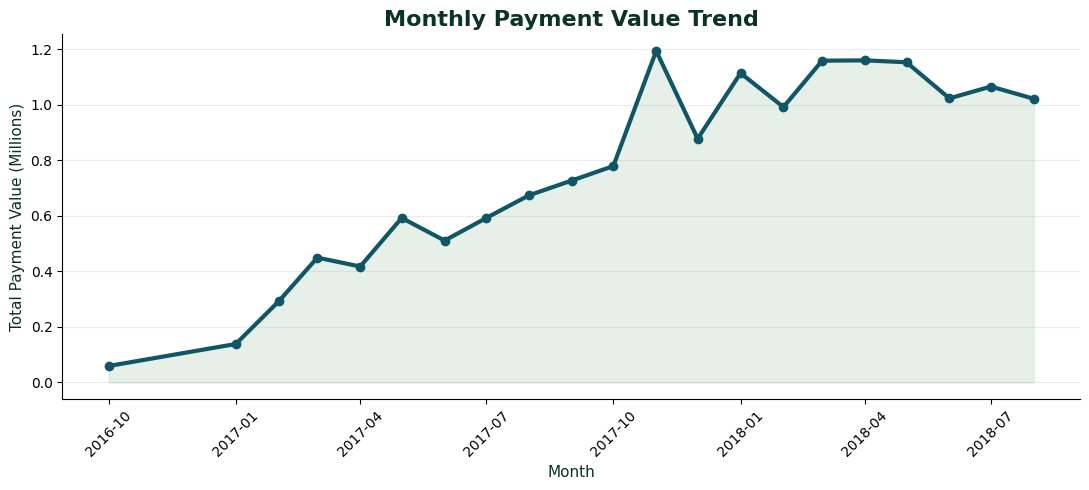

Saved chart to: C:\Users\Renuka\Desktop\Customer Revenue & Delivery Intelligence Dashboard\images\monthly_payment_value_trend.png


In [17]:
monthly_revenue = pd.read_csv(DATA_PATH / "monthly_revenue_trend.csv")

monthly_revenue["year_month_date"] = pd.to_datetime(monthly_revenue["year_month"])
monthly_revenue = monthly_revenue.sort_values("year_month_date")

fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(
    monthly_revenue["year_month_date"],
    monthly_revenue["total_payment_value"] / 1_000_000,
    marker="o",
    linewidth=3,
    color=palette["midnight_green"]
)

ax.fill_between(
    monthly_revenue["year_month_date"],
    monthly_revenue["total_payment_value"] / 1_000_000,
    color=palette["soft_bluegreen"],
    alpha=0.35
)

ax.set_title(
    "Monthly Payment Value Trend",
    fontsize=16,
    fontweight="bold",
    color=palette["dark_green"]
)

ax.set_xlabel("Month", fontsize=11, color=palette["dark_green"])
ax.set_ylabel("Total Payment Value (Millions)", fontsize=11, color=palette["dark_green"])

ax.grid(axis="y", alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.xticks(rotation=45)
plt.tight_layout()

output_path = BASE / "images" / "monthly_payment_value_trend.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")

plt.show()

print("Saved chart to:", output_path)

### Insight: Monthly Payment Value Trend

Payment value increased strongly from late 2016 into 2018. The highest payment value appears around November 2017, with several strong months continuing into 2018. This suggests that the marketplace experienced major revenue growth over time.

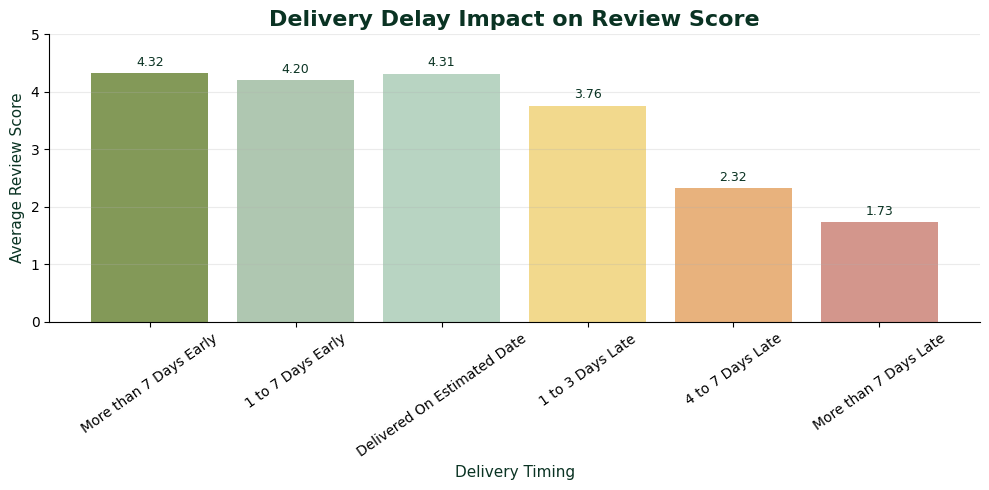

Saved chart to: C:\Users\Renuka\Desktop\Customer Revenue & Delivery Intelligence Dashboard\images\delivery_delay_impact_review_score.png


In [18]:
# Load clean delay severity data
delay_severity = pd.read_csv(DATA_PATH / "delay_severity.csv")

# Sort by our custom order
delay_severity = delay_severity.sort_values("delay_sort_order")

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(
    delay_severity["delay_bucket"],
    delay_severity["avg_review_score"],
    color=[
        palette["moss_green"],
        palette["soft_green"],
        palette["soft_bluegreen"],
        palette["warm_yellow"],
        palette["soft_orange"],
        palette["rosy_brown"]
    ]
)

ax.set_title(
    "Delivery Delay Impact on Review Score",
    fontsize=16,
    fontweight="bold",
    color=palette["dark_green"]
)

ax.set_xlabel("Delivery Timing", fontsize=11, color=palette["dark_green"])
ax.set_ylabel("Average Review Score", fontsize=11, color=palette["dark_green"])

ax.tick_params(axis="x", rotation=35)
ax.set_ylim(0, 5)

# Add review score labels
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.08,
        f"{height:.2f}",
        ha="center",
        va="bottom",
        fontsize=9,
        color=palette["dark_green"]
    )

ax.grid(axis="y", alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

output_path = BASE / "images" / "delivery_delay_impact_review_score.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")

plt.show()

print("Saved chart to:", output_path)

### Insight: Delivery Delay Impact on Review Score

Delivery timing has a strong relationship with customer satisfaction. Orders delivered early or on the estimated date have review scores above 4.20, while late orders show a clear drop in ratings. Orders delivered more than 7 days late have the lowest average review score at 1.73, showing that severe delays strongly hurt customer experience.

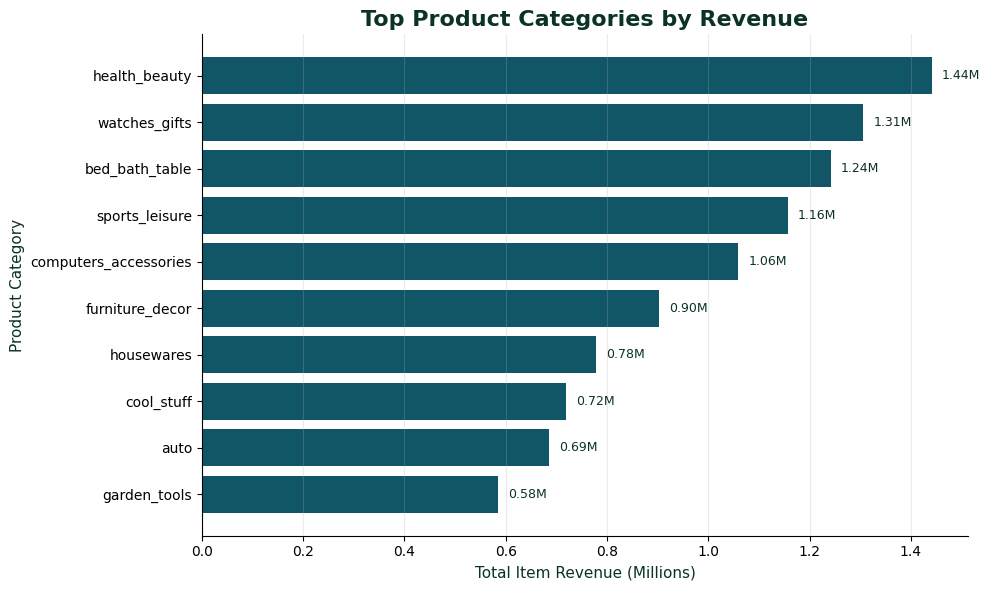

Saved chart to: C:\Users\Renuka\Desktop\Customer Revenue & Delivery Intelligence Dashboard\images\top_product_categories_revenue.png


In [19]:
# Load category performance data
category_performance = pd.read_csv(DATA_PATH / "category_performance.csv")

# Keep top 10 categories by revenue
top_categories = category_performance.head(10).sort_values(
    "total_item_revenue",
    ascending=True
)

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    top_categories["product_category"],
    top_categories["total_item_revenue"] / 1_000_000,
    color=palette["midnight_green"]
)

ax.set_title(
    "Top Product Categories by Revenue",
    fontsize=16,
    fontweight="bold",
    color=palette["dark_green"]
)

ax.set_xlabel("Total Item Revenue (Millions)", fontsize=11, color=palette["dark_green"])
ax.set_ylabel("Product Category", fontsize=11, color=palette["dark_green"])

# Add revenue labels
for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 0.02,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.2f}M",
        va="center",
        fontsize=9,
        color=palette["dark_green"]
    )

ax.grid(axis="x", alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

output_path = BASE / "images" / "top_product_categories_revenue.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")

plt.show()

print("Saved chart to:", output_path)

### Insight: Top Product Categories by Revenue

The highest revenue categories are `health_beauty`, `watches_gifts`, `bed_bath_table`, `sports_leisure`, and `computers_accessories`. These categories drive the largest share of item-level revenue and should be prioritized when analyzing marketplace performance.

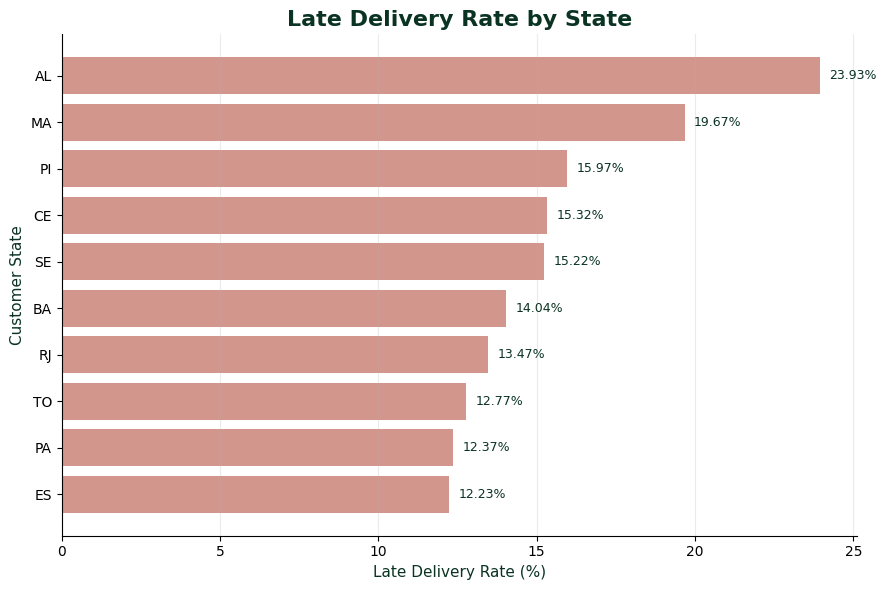

Saved chart to: C:\Users\Renuka\Desktop\Customer Revenue & Delivery Intelligence Dashboard\images\late_delivery_rate_by_state.png


In [20]:
# Load state delivery performance data
state_delivery = pd.read_csv(DATA_PATH / "state_delivery_performance.csv")

# Keep top 10 states by late delivery rate
top_late_states = state_delivery.head(10).sort_values(
    "late_order_rate",
    ascending=True
)

fig, ax = plt.subplots(figsize=(9, 6))

bars = ax.barh(
    top_late_states["customer_state"],
    top_late_states["late_order_rate"],
    color=palette["rosy_brown"]
)

ax.set_title(
    "Late Delivery Rate by State",
    fontsize=16,
    fontweight="bold",
    color=palette["dark_green"]
)

ax.set_xlabel("Late Delivery Rate (%)", fontsize=11, color=palette["dark_green"])
ax.set_ylabel("Customer State", fontsize=11, color=palette["dark_green"])

# Add percentage labels
for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.2f}%",
        va="center",
        fontsize=9,
        color=palette["dark_green"]
    )

ax.grid(axis="x", alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

output_path = BASE / "images" / "late_delivery_rate_by_state.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")

plt.show()

print("Saved chart to:", output_path)

### Insight: Late Delivery Rate by State

The states with the highest late delivery rates are AL, MA, PI, CE, and SE. AL has the highest late delivery rate at 23.93%. This suggests that regional delivery performance is uneven, and certain states may need more attention in logistics planning.

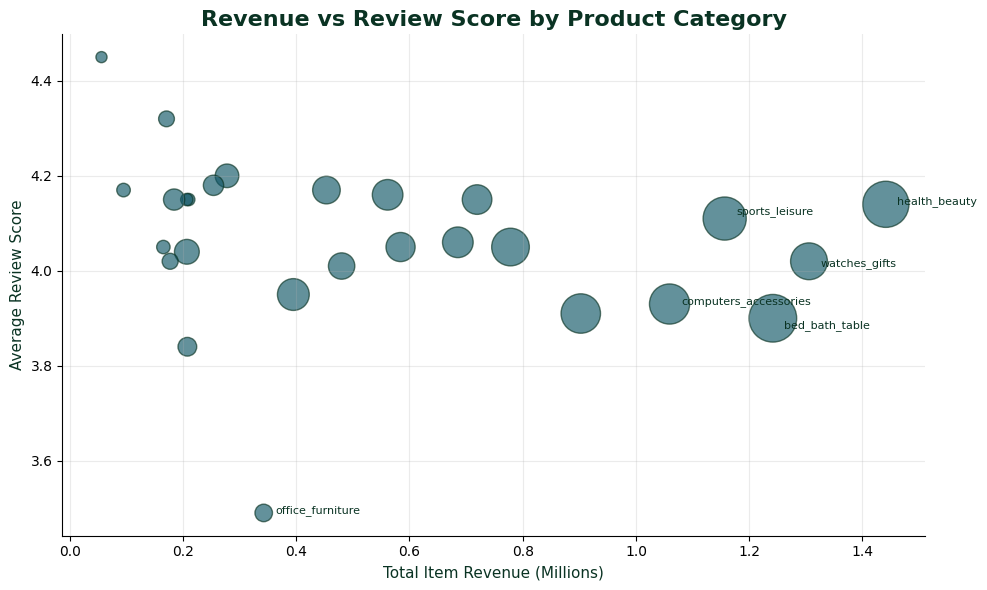

Saved chart to: C:\Users\Renuka\Desktop\Customer Revenue & Delivery Intelligence Dashboard\images\category_revenue_vs_review_score.png


In [23]:
category_performance = pd.read_csv(DATA_PATH / "category_performance.csv")

# Keep categories with meaningful order volume
category_scatter = category_performance[
    category_performance["total_orders"] >= 500
].copy()

fig, ax = plt.subplots(figsize=(10, 6))

scatter = ax.scatter(
    category_scatter["total_item_revenue"] / 1_000_000,
    category_scatter["avg_review_score"],
    s=category_scatter["total_orders"] / 8,
    color=palette["midnight_green"],
    alpha=0.65,
    edgecolor=palette["dark_green"]
)

ax.set_title(
    "Revenue vs Review Score by Product Category",
    fontsize=16,
    fontweight="bold",
    color=palette["dark_green"]
)

ax.set_xlabel("Total Item Revenue (Millions)", fontsize=11, color=palette["dark_green"])
ax.set_ylabel("Average Review Score", fontsize=11, color=palette["dark_green"])

ax.grid(alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Label important categories with slightly better spacing
important_categories = {
    "health_beauty": (0.02, 0.00),
    "watches_gifts": (0.02, -0.01),
    "bed_bath_table": (0.02, -0.02),
    "sports_leisure": (0.02, 0.01),
    "computers_accessories": (0.02, 0.00),
    "office_furniture": (0.02, 0.00)
}

for _, row in category_scatter.iterrows():
    category = row["product_category"]

    if category in important_categories:
        x_shift, y_shift = important_categories[category]

        ax.text(
            row["total_item_revenue"] / 1_000_000 + x_shift,
            row["avg_review_score"] + y_shift,
            category,
            fontsize=8,
            color=palette["dark_green"]
        )

plt.tight_layout()

output_path = BASE / "images" / "category_revenue_vs_review_score.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")

plt.show()

print("Saved chart to:", output_path)

### Insight: Revenue vs Review Score by Product Category

This chart compares product category revenue with average review score. Categories such as `health_beauty`, `watches_gifts`, and `sports_leisure` generate high revenue while maintaining review scores around 4.0 or higher.

`office_furniture` stands out as a risk category because it has meaningful revenue but a much lower average review score. This suggests that office furniture may need further investigation for product quality, delivery issues, or customer satisfaction problems.

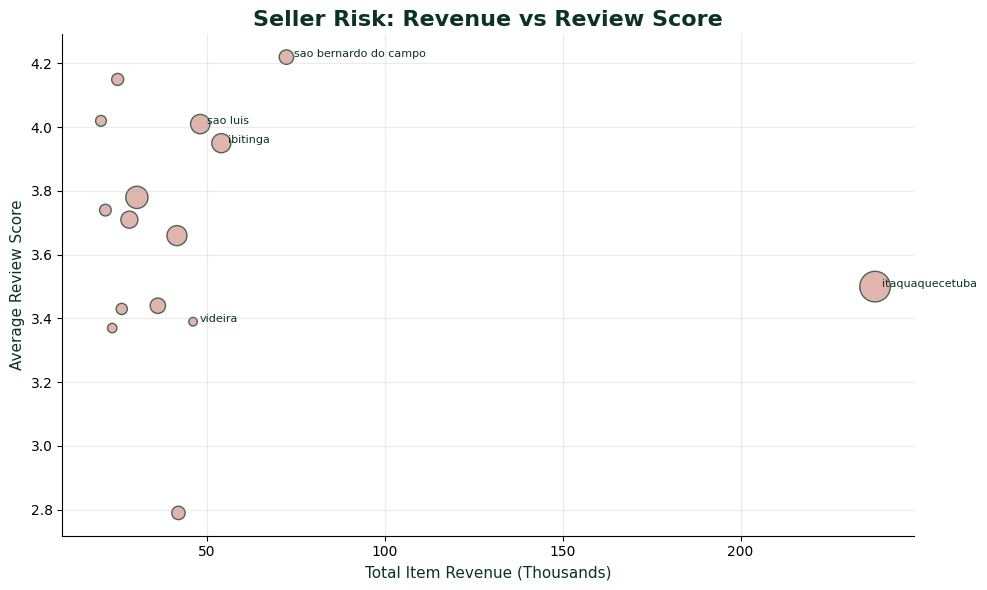

Saved chart to: C:\Users\Renuka\Desktop\Customer Revenue & Delivery Intelligence Dashboard\images\seller_risk_revenue_vs_review.png


In [24]:
# Load seller risk table
seller_risk = pd.read_csv(DATA_PATH / "seller_risk_table.csv")

fig, ax = plt.subplots(figsize=(10, 6))

scatter = ax.scatter(
    seller_risk["total_item_revenue"] / 1000,
    seller_risk["avg_review_score"],
    s=seller_risk["delivered_orders"] / 2,
    color=palette["rosy_brown"],
    alpha=0.7,
    edgecolor=palette["dark_green"]
)

ax.set_title(
    "Seller Risk: Revenue vs Review Score",
    fontsize=16,
    fontweight="bold",
    color=palette["dark_green"]
)

ax.set_xlabel("Total Item Revenue (Thousands)", fontsize=11, color=palette["dark_green"])
ax.set_ylabel("Average Review Score", fontsize=11, color=palette["dark_green"])

ax.grid(alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Label top 5 sellers by revenue
top_sellers = seller_risk.sort_values("total_item_revenue", ascending=False).head(5)

for _, row in top_sellers.iterrows():
    ax.text(
        row["total_item_revenue"] / 1000 + 2,
        row["avg_review_score"],
        row["seller_city"],
        fontsize=8,
        color=palette["dark_green"]
    )

plt.tight_layout()

output_path = BASE / "images" / "seller_risk_revenue_vs_review.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")

plt.show()

print("Saved chart to:", output_path)

### Insight: Seller Risk: Revenue vs Review Score

This chart shows flagged sellers based on revenue and review performance. The seller from `itaquaquecetuba` stands out as the biggest business risk because it has the highest item revenue among the flagged sellers while still having a weaker average review score.

This means the seller is financially important, but customer experience may need review. Other sellers have lower revenue, but some also show weaker review scores and should be monitored.

In [25]:
# Check saved chart images

images_path = BASE / "images"

saved_charts = sorted(images_path.glob("*.png"))

for chart in saved_charts:
    print(chart.name)

category_revenue_vs_review_score.png
delivery_delay_impact_review_score.png
late_delivery_rate_by_state.png
monthly_payment_value_trend.png
order_status_distribution.png
review_group_distribution.png
seller_risk_revenue_vs_review.png
top_product_categories_revenue.png


## Python EDA Summary

The Python EDA confirmed the main business findings from the SQL and Power BI analysis.

Most orders were delivered successfully, and most customers gave high reviews. However, late deliveries had a strong negative relationship with review scores. Orders delivered more than 7 days late had the lowest average review score, showing that delivery delays are a major customer satisfaction risk.

Revenue increased strongly from late 2016 into 2018. The strongest product categories by revenue were `health_beauty`, `watches_gifts`, `bed_bath_table`, `sports_leisure`, and `computers_accessories`.

The category comparison showed that `office_furniture` is a risk category because it has meaningful revenue but a much lower average review score. The seller risk chart also showed that the seller from `itaquaquecetuba` is financially important but has weaker review performance, making it a key seller to investigate.

Overall, the analysis shows that the marketplace performs well in revenue and order completion, but delivery delays, seller risk, and certain product categories should be monitored to improve customer satisfaction.